Logistic Regression with ROC curve and ROC AUC score

In [55]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn. metrics import roc_auc_score,roc_curve
from matplotlib import pyplot as plt 
import seaborn as sns 

In [56]:
## generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes= 2, random_state=1)

In [57]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [58]:
## generate a no skill prediction (majority class)
dummy_model_prob = [0 for _ in range(len(y_test))]
len(dummy_model_prob)

250

In [59]:
model=LogisticRegression()
model.fit(X_train,y_train)

## Prediction based on probability
model_prob=model.predict_proba(X_test)
model_prob


array([[9.98183500e-01, 1.81650042e-03],
       [9.88219782e-01, 1.17802177e-02],
       [3.05715722e-01, 6.94284278e-01],
       [4.51581334e-01, 5.48418666e-01],
       [2.57308951e-01, 7.42691049e-01],
       [8.65791837e-01, 1.34208163e-01],
       [7.45156970e-01, 2.54843030e-01],
       [9.45674342e-01, 5.43256581e-02],
       [3.93361441e-01, 6.06638559e-01],
       [5.62989521e-01, 4.37010479e-01],
       [8.07597282e-02, 9.19240272e-01],
       [7.37530774e-01, 2.62469226e-01],
       [2.24885866e-01, 7.75114134e-01],
       [2.59636490e-01, 7.40363510e-01],
       [9.24415321e-01, 7.55846790e-02],
       [9.92609602e-01, 7.39039835e-03],
       [7.39777327e-01, 2.60222673e-01],
       [5.22114059e-01, 4.77885941e-01],
       [2.12985067e-01, 7.87014933e-01],
       [1.36492086e-02, 9.86350791e-01],
       [7.11926953e-02, 9.28807305e-01],
       [9.35176278e-01, 6.48237225e-02],
       [9.55327404e-01, 4.46725958e-02],
       [3.22068908e-01, 6.77931092e-01],
       [9.954311

In [60]:
## focusing on positive outcome
model_prob=model_prob[:,1]
model_prob

array([1.81650042e-03, 1.17802177e-02, 6.94284278e-01, 5.48418666e-01,
       7.42691049e-01, 1.34208163e-01, 2.54843030e-01, 5.43256581e-02,
       6.06638559e-01, 4.37010479e-01, 9.19240272e-01, 2.62469226e-01,
       7.75114134e-01, 7.40363510e-01, 7.55846790e-02, 7.39039835e-03,
       2.60222673e-01, 4.77885941e-01, 7.87014933e-01, 9.86350791e-01,
       9.28807305e-01, 6.48237225e-02, 4.46725958e-02, 6.77931092e-01,
       9.00456882e-01, 6.67197049e-01, 7.96748215e-01, 3.74806548e-03,
       7.29041176e-01, 7.54750405e-01, 9.75308324e-01, 3.51079799e-01,
       9.75233401e-01, 2.17050726e-01, 4.56772430e-03, 4.68986439e-02,
       9.97926179e-01, 3.03696780e-01, 8.41132420e-01, 8.00928953e-01,
       7.25575981e-01, 4.38928821e-01, 3.00420263e-03, 3.16441108e-02,
       2.38936250e-01, 1.17276457e-01, 3.53935654e-02, 6.76814247e-01,
       1.21076164e-02, 7.39494428e-01, 6.84362460e-03, 1.17392463e-01,
       5.99340716e-01, 8.45234212e-01, 4.68425331e-01, 1.17038706e-03,
      

In [61]:
dummy_model_auc = roc_auc_score(y_test,dummy_model_prob)
model_auc = roc_auc_score(y_test,model_prob)
dummy_model_auc,model_auc

(0.5, 0.9302638319672131)

In [62]:
## calculate for roc curve
dummy_fpr, dummy_tpr, _ = roc_curve(y_test,dummy_model_prob)
model_fpr, model_tpr, thresholds = roc_curve(y_test,model_prob)

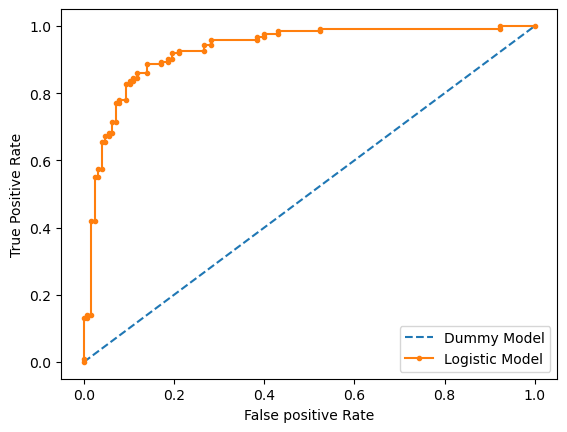

In [63]:
## plot roc curve for the model 
plt.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy Model')
plt.plot(model_fpr,model_tpr,marker='.',label='Logistic Model')
## axis labels
plt.xlabel('False positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
plt.show()

In [64]:
thresholds

array([           inf, 9.99611975e-01, 9.87394830e-01, 9.87002608e-01,
       9.86350791e-01, 9.82677366e-01, 8.94050486e-01, 8.90629187e-01,
       8.31458226e-01, 8.27993058e-01, 8.00928953e-01, 8.00077619e-01,
       7.60280097e-01, 7.54750405e-01, 7.48555413e-01, 7.42691049e-01,
       7.40363510e-01, 7.39494428e-01, 7.29041176e-01, 7.27415519e-01,
       6.77931092e-01, 6.76814247e-01, 6.71255998e-01, 6.57523926e-01,
       5.91860844e-01, 5.74316275e-01, 5.48418666e-01, 5.44940446e-01,
       5.31496639e-01, 5.28046772e-01, 4.91140353e-01, 4.77885941e-01,
       4.64232186e-01, 4.19140408e-01, 4.18979093e-01, 3.80644832e-01,
       3.72464349e-01, 3.66552180e-01, 3.53179728e-01, 3.36921498e-01,
       3.31576581e-01, 2.99249619e-01, 2.94343010e-01, 2.62469226e-01,
       2.60060050e-01, 2.01328754e-01, 1.82110879e-01, 1.55760260e-01,
       1.46938617e-01, 1.20995681e-01, 1.19586594e-01, 7.92469296e-02,
       7.58070529e-02, 3.81239834e-03, 3.74806548e-03, 6.09202021e-04])

In [65]:
import numpy as np 
np.round(2.5234,decimals=2)

np.float64(2.52)

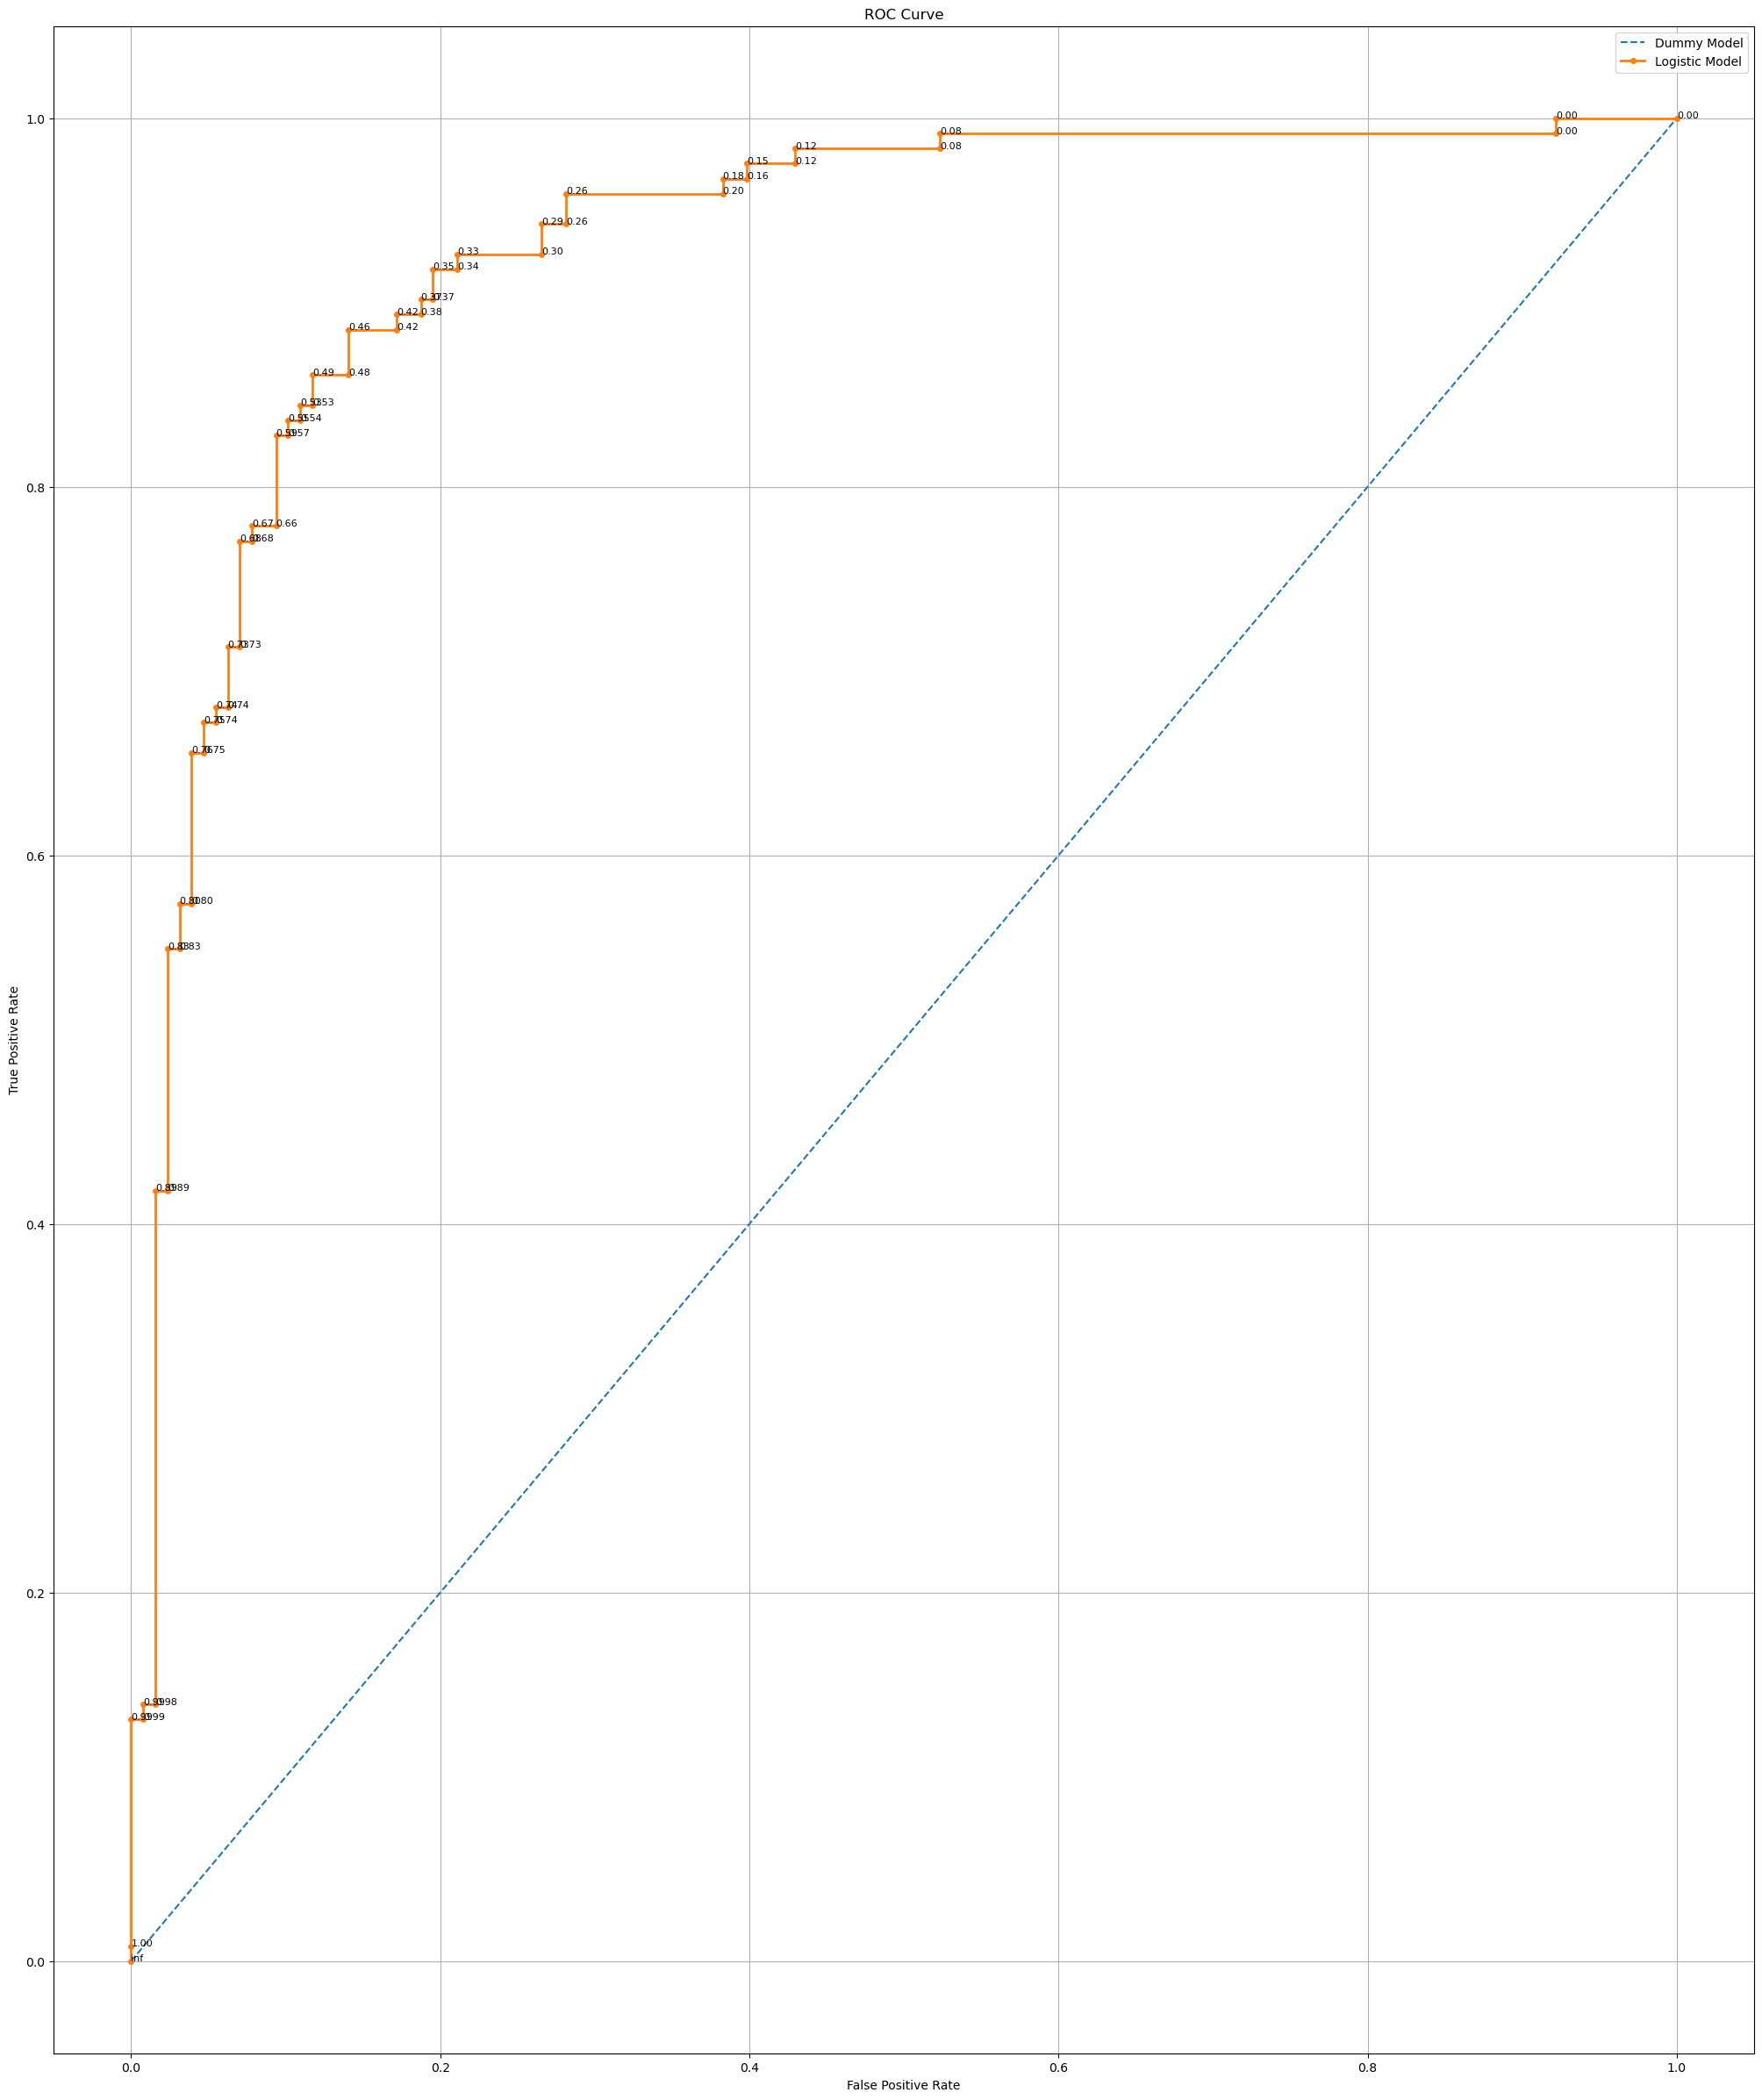

In [72]:
fig, ax = plt.subplots(figsize=(25, 30))

ax.plot(dummy_fpr, dummy_tpr, '--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, '-o', linewidth=2, markersize=4,
        label='Logistic Model')

for fpr, tpr, thr in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f"{thr:.2f}", (fpr, tpr), fontsize=8)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
ax.grid(True)

plt.show()